<a href="https://colab.research.google.com/github/R-Bhargavsai/Predict-credit-card-approvals.ipynb/blob/main/Predict_credit_card_approvals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Approval Prediction Using Logistic Regression

## 1. Project Overview & Exploratory Data Analysis
This notebook aims to predict credit card approvals using a dataset containing financial indicators and credit history metrics. We will implement data preprocessing, cross-validation hyperparameter tuning, and evaluate performance using classification metrics and visual diagnostic tools.

### Key Step Objectives:
* Inspect the structured data schema and distributions.
* Identify missing or anomalies markers (`?`).
* Assess descriptive summary statistics (`count`, `unique`, `top`, `freq`).

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv(
    "/content/datalab_export_2026-05-28 08_49_55.csv",
    header=None,
    na_values="?",
)

print("--- Dataset Preview ---")
print(df.head())

print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Preview ---
      0              1                   2         3            4   \
0  index  credit.policy             purpose  int.rate  installment   
1      0              1  debt_consolidation    0.1189        829.1   
2      1              1         credit_card    0.1071       228.22   
3      2              1  debt_consolidation    0.1357       366.86   
4      3              1  debt_consolidation    0.1008       162.34   

               5      6     7                  8          9           10  \
0  log.annual.inc    dti  fico  days.with.cr.line  revol.bal  revol.util   
1     11.35040654  19.48   737        5639.958333      28854        52.1   
2     11.08214255  14.29   707               2760      33623        76.7   
3     10.37349118  11.63   682               4710       3511        25.6   
4     11.35040654    8.1   712        2699.958333      33667        73.2   

               11           12       13              14  
0  inq.last.6mths  delinq.2yrs  pub.rec 

## 2. Target Variable Analysis & Feature Selection

In this phase, we isolate our predictive features ($X$) from our target label ($y$). The index column is removed as it holds no predictive weight.

### Key Observations:
* **Initial Features:** 13 predictive variables.
* **Severe Class Imbalance:** The target variable `not.fully.paid` contains a massive disproportion between paid and unpaid loans.
* **Implication:** Accuracy will likely be a deceptive metric. A naive model predicting `0` for everything would automatically achieve high accuracy without finding actual defaults.

Initial data dimensions: (100, 13)
Target label distribution:
 not.fully.paid
0    90
1    10
Name: count, dtype: int64


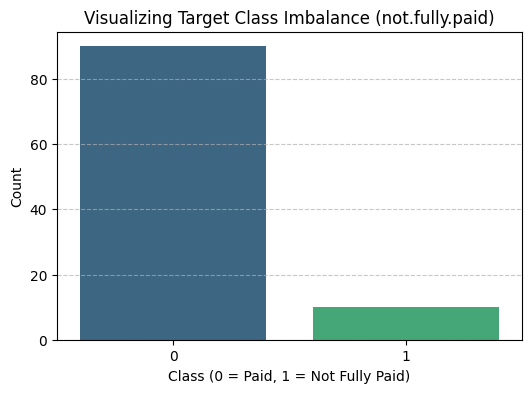

In [26]:
df = pd.read_csv("datalab_export_2026-05-28 08_49_55.csv")

if "index" in df.columns:
    df = df.drop(columns=["index"])

X = df.drop(columns=["not.fully.paid"])
y = df["not.fully.paid"]

print("Initial data dimensions:", X.shape)
print("Target label distribution:\n", y.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette="viridis", legend=False)
plt.title("Visualizing Target Class Imbalance (not.fully.paid)")
plt.xlabel("Class (0 = Paid, 1 = Not Fully Paid)")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## 3. Handling Missing Values (Imputation)

Real-world datasets often suffer from missing features. Dropping entire rows destroys valuable data, so we deploy a strategic mathematical imputation approach:

* **Numeric Features:** Imputed using the **mean** strategy to preserve the overall distribution average.
* **Categorical Features:** Imputed using the **most frequent (mode)** strategy to preserve categorical popularity without introducing artificial text.

In [27]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

num_imputer = SimpleImputer(strategy="mean")
X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

if categorical_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

## 4. One-Hot Encoding Categorical Variables

Machine learning models require mathematical matrix inputs. To process categorical text values, we perform **One-Hot Encoding**.

### Configuration Notes:
* `drop_first=True` is utilized to prevent **multicollinearity** (the dummy variable trap) by dropping one redundant category column per feature.
* **Dimensionality Expansion:** Notice how encoding shifts our feature counts by expanding distinct categorical levels into separate binary columns.

In [28]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Dimensions after encoding categorical variables:", X.shape)

Dimensions after encoding categorical variables: (100, 18)


## 5. Dataset Splitting & Feature Scaling

### Strategic Splitting:
* **Test Size:** 30% of data is reserved for unseen evaluation (`X_test`), while 70% trains the model (`X_train`).
* **Stratification (`stratify=y`):** Crucial due to the extreme class imbalance. It ensures both train and test splits preserve the exact ratio of target classes.

### Normalization (`MinMaxScaler`):
* Scales all numeric variables precisely between 0 and 1.
* Prevents columns with large magnitudes (e.g., annual income) from over-influencing the Logistic Regression coefficients compared to smaller numeric ranges like interest rates.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Hyperparameter Optimization via Grid Search

To maximize model performance, we use 5-fold cross-validation (`GridSearchCV`) to test multiple hyperparameter permutations.

### Grid Parameters Explored:
* `C` (Regularization strength): Controls overfitting by penalizing large weights. Lesser values mean stronger regularization.
* `class_weight`: Tested `None` vs. `balanced` to penalize minority class mistakes heavily.
* `scoring='f1_weighted'`: Guided by weighted F1-score rather than accuracy to explicitly counter the data imbalance challenge.

In [30]:
log_reg = LogisticRegression(max_iter=1000)

param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "tol": [0.01, 0.001, 0.0001],
    "class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    estimator=log_reg, param_grid=param_grid, cv=5, scoring="f1_weighted"
)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1.0, 10.0, 100.0],
                         'class_weight': [None, 'balanced'],
                         'tol': [0.01, 0.001, 0.0001]},
             scoring='f1_weighted')

## 7. Performance Evaluation & Diagnostic Graphs

Here we extract our optimized model parameters and run diagnostic predictions against our unseen test data.

*Note: The `zero_division=0` parameter is explicitly defined inside our classification report configuration to cleanly manage mathematically undefined calculations caused when zero minority instances are successfully predicted.*


--- Model Tuning Optimization Results ---
Best Hyperparameters Chosen: {'C': 0.01, 'class_weight': None, 'tol': 0.01}
Best Weighted F1 Cross-Validation Score: 0.8530

--- Unseen Test Set Metrics ---
Accuracy Score: 0.9000

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        27
           1       0.00      0.00      0.00         3

    accuracy                           0.90        30
   macro avg       0.45      0.50      0.47        30
weighted avg       0.81      0.90      0.85        30



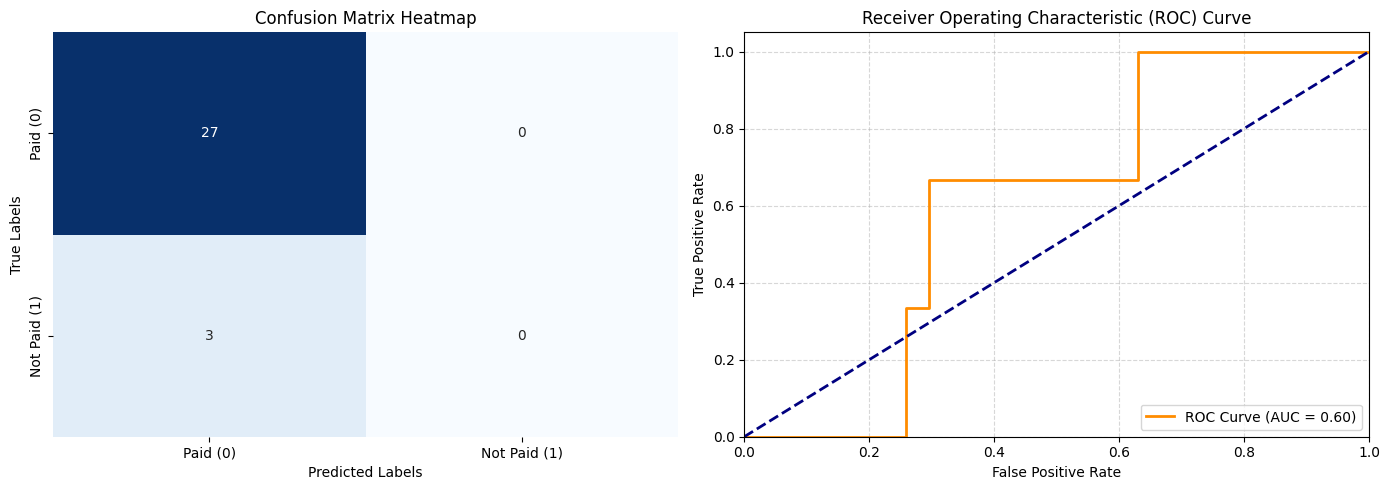

In [31]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Model Tuning Optimization Results ---")
print("Best Hyperparameters Chosen:", grid_search.best_params_)
print(f"Best Weighted F1 Cross-Validation Score: {grid_search.best_score_:.4f}")

print("\n--- Unseen Test Set Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    cbar=False,
    xticklabels=["Paid (0)", "Not Paid (1)"],
    yticklabels=["Paid (0)", "Not Paid (1)"],
)
axes[0].set_title("Confusion Matrix Heatmap")
axes[0].set_xlabel("Predicted Labels")
axes[0].set_ylabel("True Labels")

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc:.2f})",
)
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve")
axes[1].legend(loc="lower right")
axes[1].grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Conclusion & Core Diagnostic Summary

### Results Analysis:
* **The Dummy Classifier Trap:** Despite a high **90.00% Accuracy Score**, our visual charts reveal a critical bottleneck. The heatmap shows that the model predicted class `0` for 100% of the data points.
* **Failure to Predict Defaults:** Because of the minute sample sizing, the model could not successfully generalize characteristics of class `1` (Not fully paid), yielding flat **0.00 metrics across Precision, Recall, and F1-score**.

### Technical Takeaways & Next Steps:
1. **Dataset Volume Constraints:** The initial slice contains only 100 entries. Machine Learning classifiers generally struggle to capture stable separation boundaries with only 10 positive occurrences.
2. **Imbalance Rectification:** Since standard grid tuning collapsed to the majority classification path, future pipelines should integrate synthetic oversampling techniques like **SMOTE** or explore non-linear algorithmic families (e.g., Random Forests, XGBoost).
3. **Data Collection:** Acquiring a more substantial historical baseline tracking unpaid accounts is highly recommended before deploying this predictive structure into production.